In [185]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [186]:
pip install corner

Note: you may need to restart the kernel to use updated packages.


In [187]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import r2_score, mean_absolute_error
import emcee
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cude" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [203]:
#Testdatan, echte Punkte aus deer Dissertation
real_points = [
    # Point V[f]  f[kHz] T[C°]  K        n      Lifetime
    ("I",   350,   10,   250,   426,   0.0275,   1200), #(Keine direkte Probe, konservative Schätzung aus ähnlichen Bedingungen (350 V / 10 kHz / 250 °C), passt zu No. 20, 36, 37)
    ('II',  350,   4,   220,  592,   0.0441,  2610),
    ('III', 400,   4,   250,  475,   0.0104,   740), #Annäherung an No. 34 (400 V / 10 kHz / 250 °C → 741 h), fast identisch
    ('IV',  400,  10,   220,  546,   0.0468,   741), 
    ('V',   450,   4,   220,  533,   0.0303,   430),
    #('VI',  450,  10,   250,  502,   0.0184,   246),
    ('VII', 400,  10,   250,  546,   0.0468,   657),   # Mittelwert aus No. 21 (573 h) und No. 34 (741 h), beide exakt gleiche Bedingungen
    ('VIII',400,   4,   220,  559,   0.0418,  1922),  # hier genauso, Mittel aus 1586+2258 (No.32 und No. 35)
    #('IX',  350,   4,   250,  535,   0.0482,   246), #ähnlich wie Point VI
    ('X',   350,  10,   220,  547,   0.0323,  1224),
    ]

In [204]:
#potten der Testkurve # Erst die Hilfsfunktion unten ausfühen ipm_model()
#for i in real_points:
    #t = np.linspace(0, i[6], i[6])
    #pdiv = ipm_model(t,i[4],i[5])
    #plt.grid(True)
    #plt.plot(t, pdiv, 'b-', linewidth=1, alpha=0.5, )

In [205]:
#import numpy as np
#import matplotlib.pyplot as plt

#points = [
    #('I', 426, 0.0275, 930),
    #('II', 592, 0.0441, 2031),
    #('III', 475, 0.0104, 245),
    #('IV', 546, 0.0468, 740),
    #('V', 533, 0.0303, 445),
    #('VI', 502, 0.0184, 245),
    #('VII', 546, 0.0468, 742),
    #('VIII', 559, 0.0418, 2258),
    #('IX', 535, 0.0482, 1896),
    #('X', 547, 0.0323, 1224),
#]

#max_t = max(lifetime for _, _, _, lifetime in points) + 100  
#t = np.linspace(1, max_t, 2000)

#plt.figure(figsize=(12, 7))
#colors = plt.cm.tab10(np.linspace(0, 1, 10))

#for i, (label, K, n, lifetime) in enumerate(points):
    #PDIV = K * t ** (-n)
    #t_plot = t[t <= lifetime + 50] 
    #PDIV_plot = PDIV[:len(t_plot)]
    #plt.plot(t_plot, PDIV_plot, color=colors[i], label=f'Point {label} (lifetime {lifetime}h)')

#plt.xlabel('Time [h]')
#plt.ylabel('PDIV [V]')
#plt.title('IPM Fits')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid(True)
#plt.xlim(0, max_t)
#plt.ylim(300, 700)
#plt.tight_layout()
#plt.show()

In [206]:
def generate_imp_curve(K, n, lifetime_hours, noise_std=15, points=1200):
    t = np.linspace(1, lifetime_hours*1.4, points) 
    PDIV_clean = K * t ** (-n)
    PDIV = PDIV_clean + np.random.normal(0, noise_std, points)
    PDIV = np.clip(PDIV, 300, K+100) # Grenzen (realistisch)
    return t, PDIV

In [207]:
#Variante 1
#Daten generieren, Fester Grenzwert

PDIV_THRESHOLD = 420         
train_data = []
for i in range(2000):
    base = real_points[np.random.randint(len(real_points))]
    K = np.random.normal(base[4], 30)
    n = np.random.normal(base[5], 0.008)
    K = max(K, 400)
    n = max(n, 0.005)

    PDIV0 = K
    t_search = np.linspace(1, 15000, 30000)    # grobe Suche
    PDIV_search = K * t_search ** (-n)
    lifetime_idx = np.where(PDIV_search <= PDIV_THRESHOLD)[0]

    if len(lifetime_idx) > 0:
        lifetime = int(t_search[lifetime_idx[0]])
    else:
        lifetime = 1200 
    # Kurve erzeugen
    t_full, PDIV_full = generate_imp_curve(K, n, lifetime, noise_std=5)
    train_data.append({
        "id": i, "K": K, "n": n, "lifetime": lifetime,"t": t_full,"PDIV": PDIV_full
    })



#Variante 2
#  Daten generieren, Zufälliger/Variabler Grenzwert
#train_data = []
#for i in range(250):
    #zufällig einen Punkt aus den echten Punkten auswählen, als Basis
    #base = real_points[np.random.randint(len(real_points))]
    #K = np.random.normal(base[4], 30) #+- 30 um den realen K wert
    #n = np.random.normal(base[5], 0.008) #hier auch eine kleine streuung in n
    #K = max(K, 400)
    #n = max(n, 0.005)
    #lifetime = np.random.uniform(200, 3000)

    #t, PDIV = generate_imp_curve(K, n, lifetime)
    #train_data.append({"id": i, "K": K, "n": n, "lifetime": lifetime, "t": t, "PDIV": PDIV})





# Testdaten (die echten 10 Ponits aus der Dissertation)
#test_data = []
#for p in real_points: 
    #t, PDIV = generate_imp_curve(p[4], p[5], p[6], noise_std=5)
    #test_data.append({"point": p[0], "K": p[4], "n": p[5], "lifetime": p[6], "t": t, "PDIV": PDIV})


#print(f"Training data: {len(train_data)} synthetische Motoren")
#print(f"Test data: {len(test_data)} echte Punkte aus der Dissertation")

In [208]:
test_data = []
for idx, p in enumerate(real_points):
    # Streuung wie im Training
    K_true = np.random.normal(p[4], 30)
    n_true = np.random.normal(p[5], 0.008)
    K_true = max(K_true, 400)
    n_true = max(n_true, 0.005)
    
    # Lifetime neu berechnen (wie im Training)
    t_search = np.linspace(1, 15000, 30000)
    PDIV_search = K_true * t_search ** (-n_true)
    lifetime_idx = np.where(PDIV_search <= PDIV_THRESHOLD)[0]
    lifetime = p[6]#int(t_search[lifetime_idx[0]]) if len(lifetime_idx)>0 else 1200
    
    # Vollkurve mit stärkerem Rauschen generieren (realistischer)
    t_full, PDIV_full = generate_imp_curve(K_true, n_true, lifetime, noise_std=15)
    
    test_data.append({
        "point": p[0],
        "K_true": K_true, "n_true": n_true,  # zum Debuggen
        "lifetime": lifetime,
        "t": t_full, "PDIV": PDIV_full
    })

In [168]:
#test_data[3]

In [169]:
#test_data[3]["t"], test_data[3]["PDIV"]

In [170]:
#plt.plot(test_data[3]["t"], test_data[3]["PDIV"])

In [209]:
#Feature Extractio. PDIV an festen frühen Zeiten 
def extract_early_pdiv(t_vec, pdiv_vec, early_fraction=0.10):
    n= int(early_fraction * len(pdiv_vec))
    early_t = t_vec[:n]
    early_pdiv = pdiv_vec[:n]
    target_times = np.linspace(50, 800, 80) #[100, 200, 300, 400, 500, 600, 700, 800] 
    features = []
    for tt in target_times: 
        if early_t[-1]< tt:
            features.append(early_pdiv[-1])
        else:
            idx = np.argmin(np.abs(early_t - tt))
            features.append(early_pdiv[idx])
    return np.array(features)



X_train = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in train_data])
y_train = np.array([m["lifetime"] for m in train_data])

X_test = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in test_data])
y_test = np.array([m["lifetime"] for m in test_data])

#Normalisierung
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - X_mean)/ (X_std + 1e-8)
X_test_norm = (X_test - X_mean)/ (X_std + 1e-8)


y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean)/ y_std
y_test_real = y_test

In [210]:
X_train, y_train.shape, X_test.shape, y_test.shape

(array([[457.01614531, 457.01614531, 457.01614531, ..., 457.01614531,
         457.01614531, 457.01614531],
        [452.89102849, 451.64329516, 448.99879951, ..., 447.99811746,
         447.99811746, 447.99811746],
        [420.19300365, 420.19300365, 420.19300365, ..., 420.19300365,
         420.19300365, 420.19300365],
        ...,
        [469.10270219, 460.29451096, 459.48748119, ..., 461.22084598,
         461.22084598, 461.22084598],
        [483.74016261, 490.01311856, 490.41158876, ..., 484.1368754 ,
         484.1368754 , 484.1368754 ],
        [459.04172762, 459.04172762, 459.04172762, ..., 459.04172762,
         459.04172762, 459.04172762]], shape=(2000, 80)),
 (2000,),
 (8, 80),
 (8,))

In [211]:
#X_test[1], y_test[1]

In [212]:
#ResNet-CNN 

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(),
            nn.Conv1d(c,c,3,padding=1),
            nn.BatchNorm1d(c)
        )
    
    def forward(self, x):
        return nn.ReLU()(self.net(x) + x)

class ResNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1,64,7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64,128,3, padding=1),
            nn.ReLU(),
            ResBlock(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x).flatten(1)
        return self.fc(x).squeeze(-1)

In [213]:
model = ResNetCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.0015, weight_decay=1e-5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_norm), torch.FloatTensor(y_train_norm)),
batch_size=32, shuffle=True,)

#Model mit den bestem Loss speichern
best_loss = float("inf")
best_model_state = None
best_epoch = -1

#Model trainieren
model.train()
for epoch in range(20):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch
        print(f"Best model, Epoch: {epoch:3d}, Loss: {epoch_loss:.6f} saved")
    
    #if epoch % 10 == 0:
    print(f"Epoch: {epoch:3d}, Loss: {epoch_loss:.6f}")

#Best Model laden und speichern
print(f"Trainin finished, best model saved, Epoch: {best_epoch:3d}, Loss: {best_loss:.6f}")
model.load_state_dict(best_model_state)

#speichern
import os
os.makedirs("saved_models", exist_ok=True)
torch.save({
        'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'loss': best_loss,
    'X_mean': X_mean,
    'X_std': X_std,
    'y_mean': y_mean,
    'y_std': y_std
}, "saved_models/res_cnn_motor_best.pth")

print("Model saved")


#Evaluationsteil 
model.eval()
with torch.no_grad():
    pred_norm = model(torch.FloatTensor(X_test_norm).to(device)).cpu().numpy()
    pred_life = pred_norm * y_std + y_mean


r2_s1 = r2_score(y_test_real, pred_life)
mae_s1 = mean_absolute_error(y_test_real, pred_life)
print(f"Auf den 8 Punkten aus der Dissertation")
print(f"R2: {r2_s1:.4f}, MAE: {mae_s1:.1f}")



Best model, Epoch:   0, Loss: 0.358529 saved
Epoch:   0, Loss: 0.358529
Best model, Epoch:   1, Loss: 0.162500 saved
Epoch:   1, Loss: 0.162500
Best model, Epoch:   2, Loss: 0.120814 saved
Epoch:   2, Loss: 0.120814
Epoch:   3, Loss: 0.120847
Best model, Epoch:   4, Loss: 0.088693 saved
Epoch:   4, Loss: 0.088693
Epoch:   5, Loss: 0.189594
Epoch:   6, Loss: 0.104698
Epoch:   7, Loss: 0.100001
Epoch:   8, Loss: 0.094809
Best model, Epoch:   9, Loss: 0.080634 saved
Epoch:   9, Loss: 0.080634
Best model, Epoch:  10, Loss: 0.076927 saved
Epoch:  10, Loss: 0.076927
Best model, Epoch:  11, Loss: 0.062379 saved
Epoch:  11, Loss: 0.062379
Best model, Epoch:  12, Loss: 0.059050 saved
Epoch:  12, Loss: 0.059050
Best model, Epoch:  13, Loss: 0.045815 saved
Epoch:  13, Loss: 0.045815
Epoch:  14, Loss: 0.068663
Epoch:  15, Loss: 0.052760
Best model, Epoch:  16, Loss: 0.042608 saved
Epoch:  16, Loss: 0.042608
Best model, Epoch:  17, Loss: 0.040556 saved
Epoch:  17, Loss: 0.040556
Best model, Epoch: 

In [216]:
# Bayesian Stage 2
def ipm_model(t, K, n):
    return K * t **(-n)

#def log_likelihood(theta, t_obs, pdiv_obs, sigma=15.0):
    #K, log_n = theta 
    #n = np.exp(log_n) # n > 0
    #if K < 300 or K >800 or log_n < -6.0 or log_n > -2.0:
        #return -np.inf
    #model_pred = ipm_model(t_obs, K, n)
    #residual = pdiv_obs - model_pred
    #return -0.5 * np.sum(residual**2 / sigma**2 + np.log(2*np.pi*sigma**2))

def log_prior(theta):
    K, log_n = theta
    #n = np.exp(log_n)
    if 400 < K < 700 and -6.0 < log_n < -2.0: # n zwischen 0.0025 und 0.135
        return 0.0
    return -np.inf

#def log_posterior(theta, t_obs, pdiv_obs):
    #lp = log_prior(theta)
    #if not np.isfinite(lp):
        #return -np.inf
    #return lp + log_likelihood(theta, t_obs, pdiv_obs)

# === NEUE Likelihood mit Modell-Unsicherheit (Error Propagation) ===
def log_likelihood(theta, t_obs, pdiv_obs, base_cov, sigma_meas=15.0):
    K, log_n = theta
    n = np.exp(log_n)
    
    if K < 300 or K > 800 or log_n < -6.0 or log_n > -2.0:
        return -np.inf
    
    model_pred = ipm_model(t_obs, K, n)
    
    # Jacobi-Matrix für Error Propagation: ∂PDIV/∂(K, n)
    J_K = t_obs ** (-n)                          # ∂/∂K
    J_n = -K * np.log(t_obs) * t_obs ** (-n)     # ∂/∂n
    
    J = np.column_stack([J_K, J_n])
    
    # Varianz durch Parameter-Unsicherheit des Base-Modells
    model_var = np.diag(J @ base_cov @ J.T)
    
    # Totale Varianz = Messrauschen² + Modell-Unsicherheit
    total_var = sigma_meas**2 + model_var
    
    residual = pdiv_obs - model_pred
    return -0.5 * np.sum(
        residual**2 / total_var + np.log(2 * np.pi * total_var)
    )

# Angepasste Posterior-Funktion
def log_posterior(theta, t_obs, pdiv_obs, base_cov):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t_obs, pdiv_obs, base_cov)

In [184]:
#t_full, t_obs

In [183]:
#idx = 1 #hier ändern, um verschiedene Punkte zu testen (10 Motoren)
#motor = test_data[idx]
#t_full = motor['t']
#pdiv_full = motor['PDIV']
#true_life = motor['lifetime']
#cnn_life = pred_life[idx]

#t_full,pdiv_full, true_life, cnn_life

In [179]:
#for i in range(10):
    
    #print(curves[i])
    #print(curves[i].shape)
    #y = curves[i]
    #x = np.linspace(1, curves[i].shape[0], curves[i].shape[0])
    #print(x.shape)
    #plt.plot(x, y)
    #plt.show()


In [215]:
# === Base-Fits auf die vollständigen Testkurven (für Modell-Unsicherheit) ===
from scipy.optimize import curve_fit

print("Fitting IPM auf vollständige Testkurven für Modell-Unsicherheit...")
base_fits = []

for motor in test_data:
    t_full = motor['t']
    pdiv_full = motor['PDIV']
    
    try:
        popt, pcov = curve_fit(
            ipm_model, t_full, pdiv_full,
            p0=[600, 0.04],
            bounds=([300, 0.001], [800, 0.1]),
            maxfev=5000
        )
        perr = np.sqrt(np.diag(pcov))  # Standardabweichung der Parameter
        base_fits.append({
            "K_fit": popt[0],
            "n_fit": popt[1],
            "K_std": perr[0],
            "n_std": perr[1],
            "cov": pcov
        })
    except:
        # Falls Fit fehlschlägt, fallback
        base_fits.append({
            "K_fit": motor['K_true'],
            "n_fit": motor['n_true'],
            "K_std": 30,
            "n_std": 0.008,
            "cov": np.eye(2) * 100
        })

print("Base-Fits fertig")

Fitting IPM auf vollständige Testkurven für Modell-Unsicherheit...
Base-Fits fertig


Stage 2 für Point I, echte Lebensdauer: 1200h


  0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 6000/6000 [00:16<00:00, 369.82it/s]


Accepted 6400 samples, K = 417.8 ± 6.3, n = 0.01980 ± 0.02385


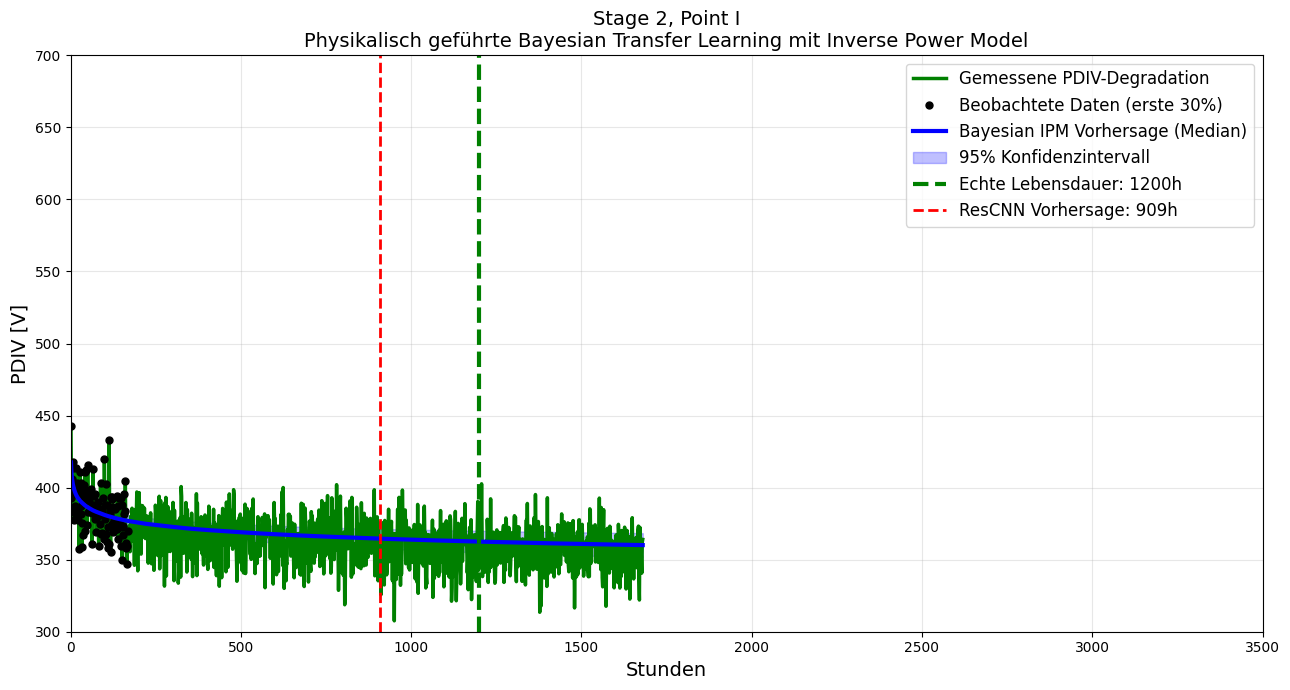

 R² stage 2: 0.9533
 MAE: 0.95 V
Stage 2 für Point II, echte Lebensdauer: 2610h


100%|██████████| 6000/6000 [00:15<00:00, 381.31it/s]


Accepted 6400 samples, K = 618.3 ± 7.6, n = 0.03842 ± 0.04098


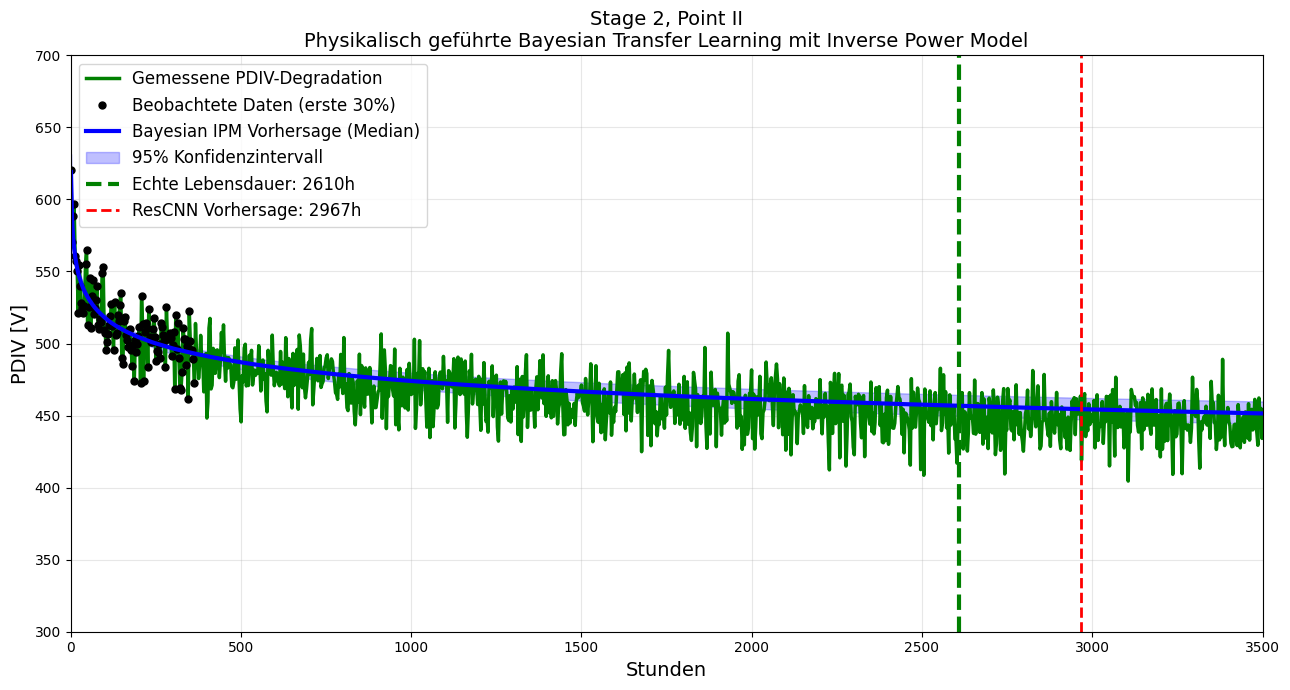

 R² stage 2: 0.9988
 MAE: 0.37 V
Stage 2 für Point III, echte Lebensdauer: 740h


100%|██████████| 6000/6000 [00:14<00:00, 402.47it/s]


Accepted 6400 samples, K = 453.1 ± 4.0, n = 0.00492 ± 0.00734


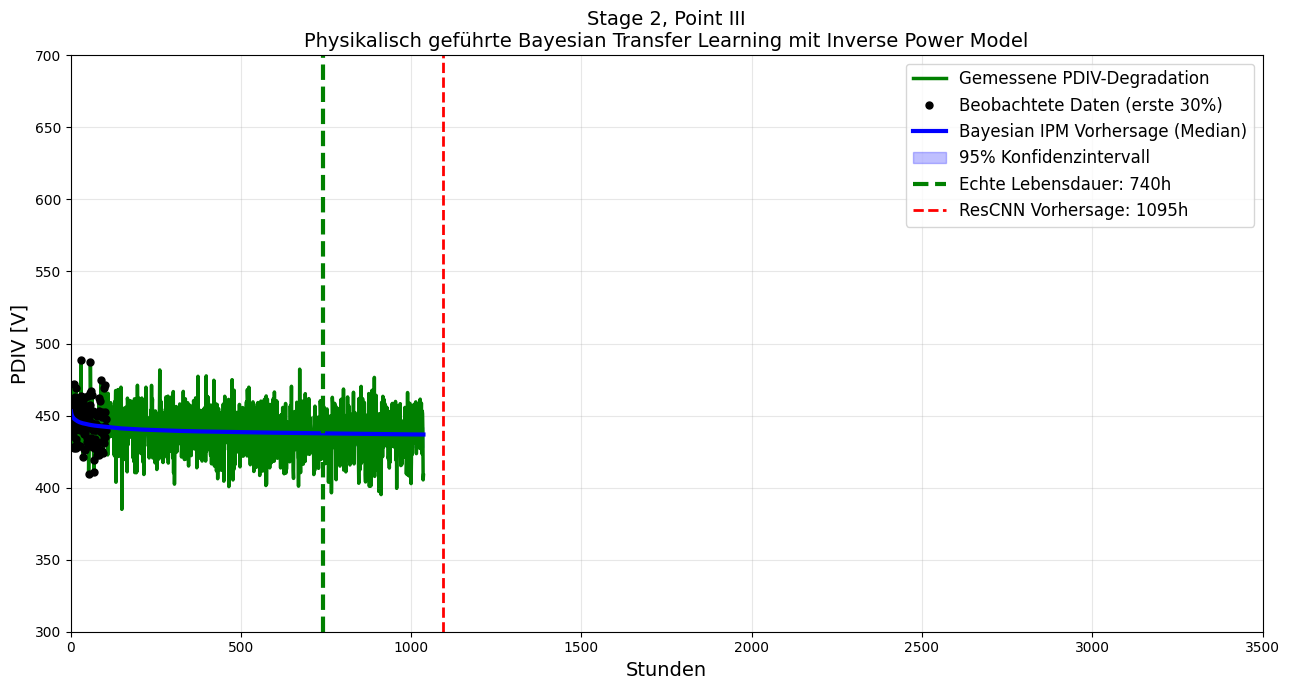

 R² stage 2: 0.9782
 MAE: 0.18 V
Stage 2 für Point IV, echte Lebensdauer: 741h


100%|██████████| 6000/6000 [00:15<00:00, 375.25it/s]


Accepted 6400 samples, K = 519.2 ± 6.3, n = 0.05669 ± 0.06007


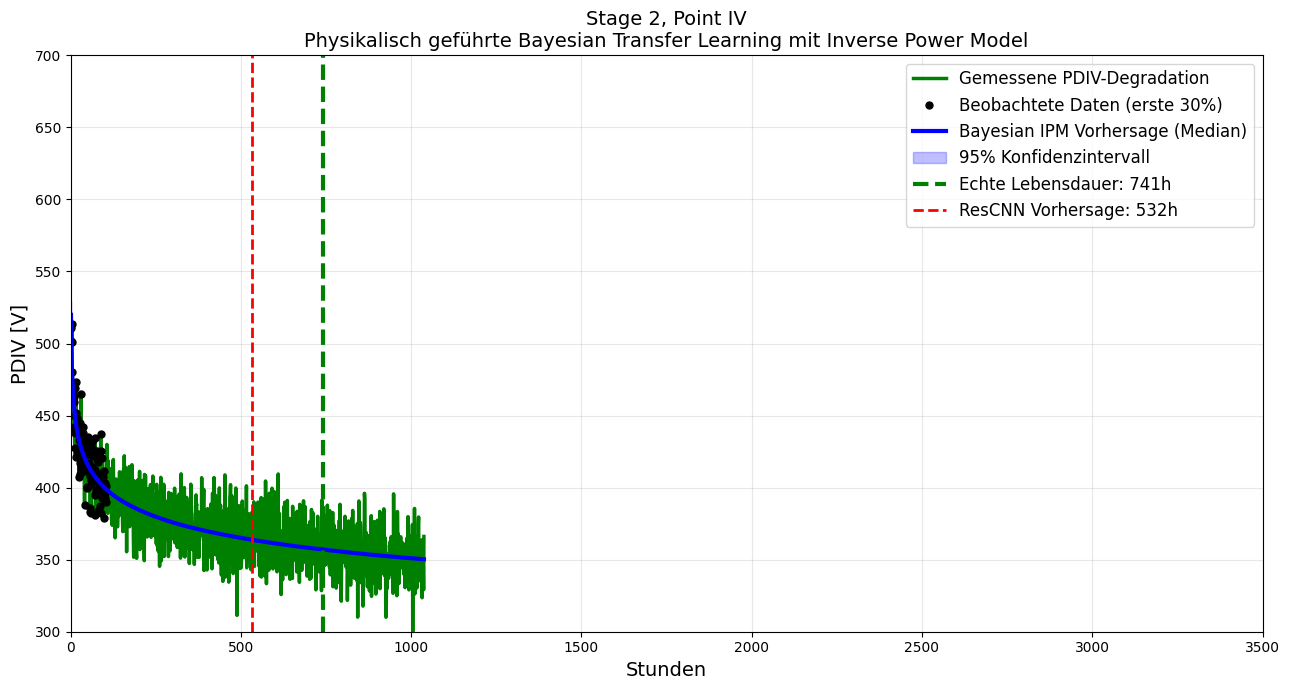

 R² stage 2: 0.9992
 MAE: 0.35 V
Stage 2 für Point V, echte Lebensdauer: 430h


100%|██████████| 6000/6000 [00:16<00:00, 368.24it/s]


Accepted 6400 samples, K = 540.2 ± 5.5, n = 0.03557 ± 0.03890


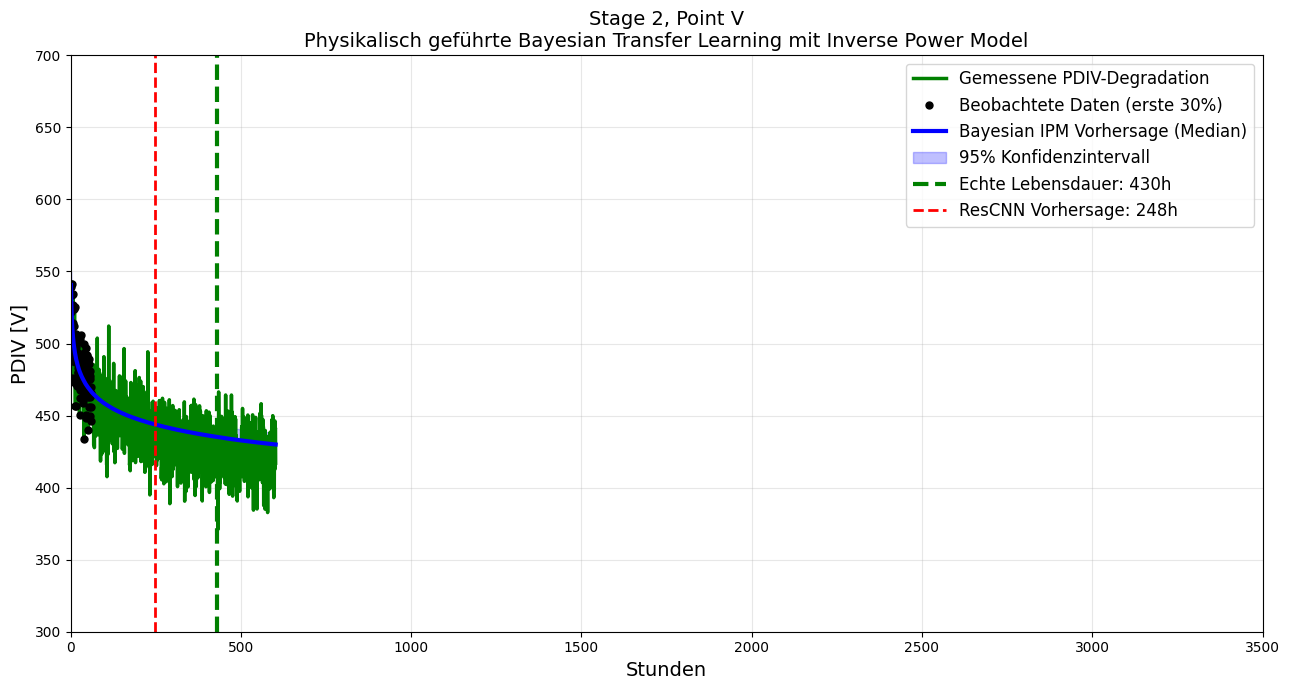

 R² stage 2: 0.9980
 MAE: 0.41 V
Stage 2 für Point VII, echte Lebensdauer: 657h


100%|██████████| 6000/6000 [00:17<00:00, 340.09it/s]


Accepted 6400 samples, K = 515.4 ± 6.0, n = 0.03071 ± 0.03412


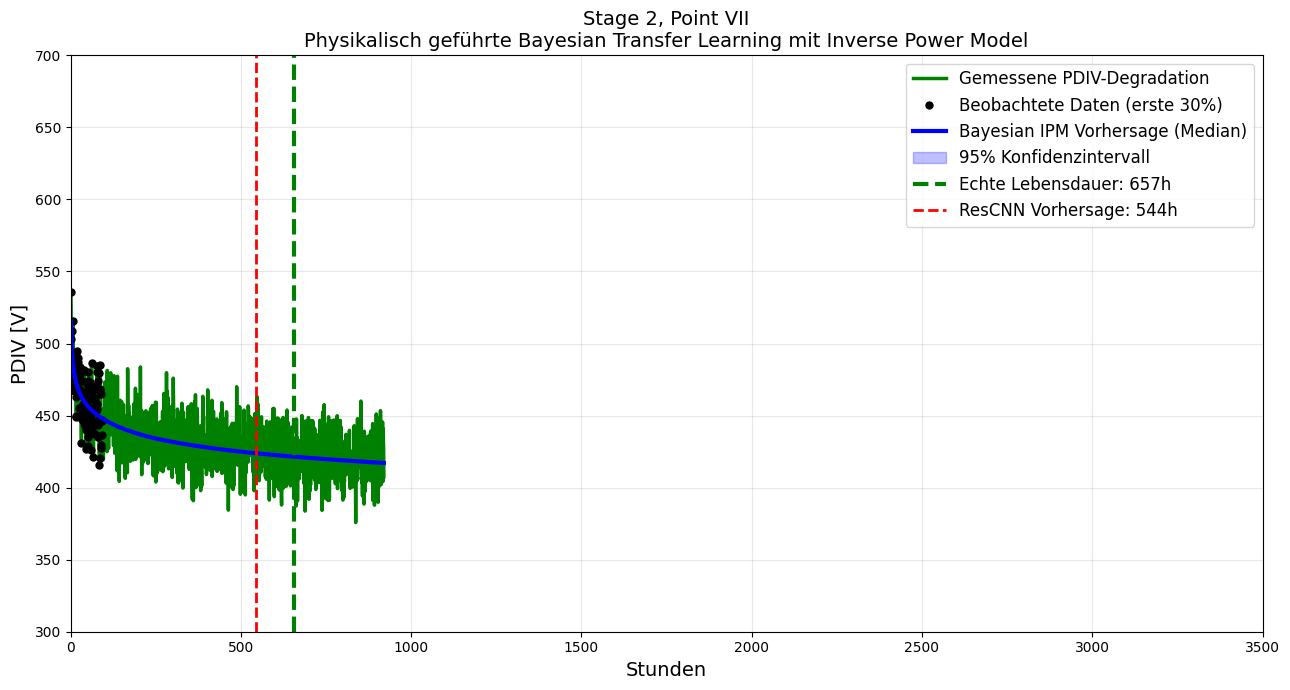

 R² stage 2: 0.9997
 MAE: 0.11 V
Stage 2 für Point VIII, echte Lebensdauer: 1922h


100%|██████████| 6000/6000 [00:15<00:00, 375.77it/s]


Accepted 6400 samples, K = 561.0 ± 7.3, n = 0.03718 ± 0.04009


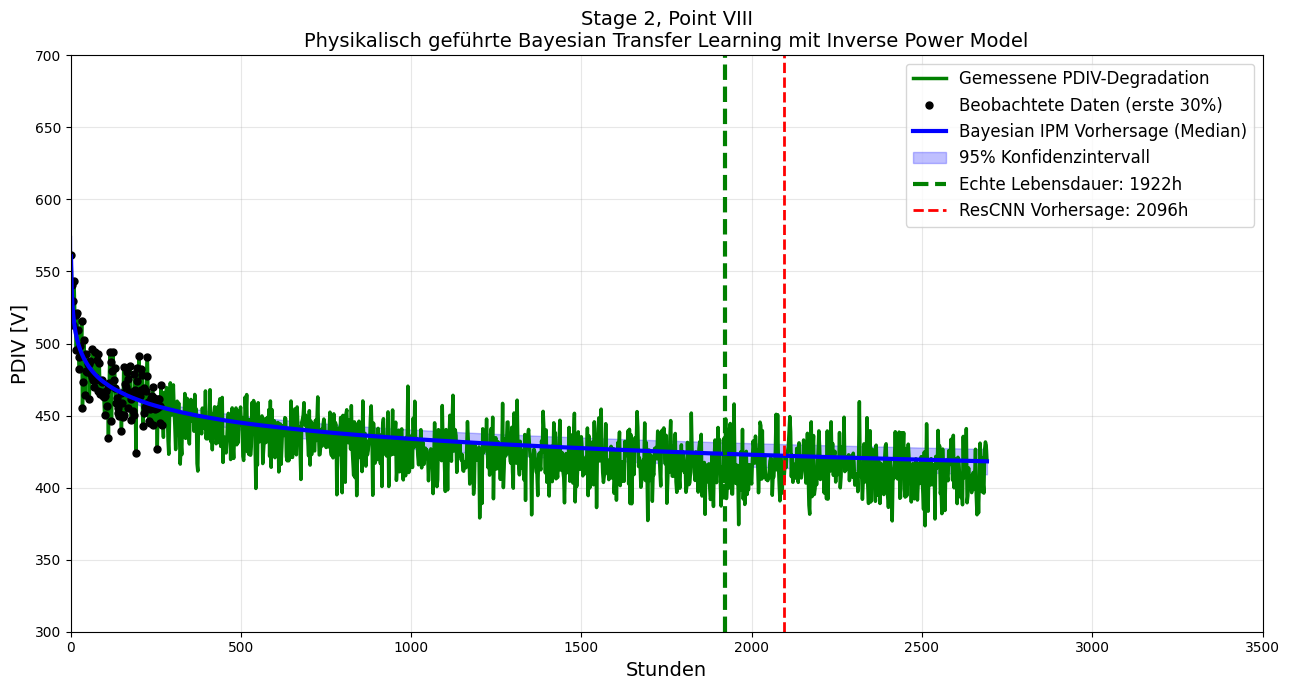

 R² stage 2: 0.9963
 MAE: 0.56 V
Stage 2 für Point X, echte Lebensdauer: 1224h


100%|██████████| 6000/6000 [00:15<00:00, 375.94it/s]


Accepted 6400 samples, K = 603.6 ± 6.7, n = 0.03756 ± 0.04030


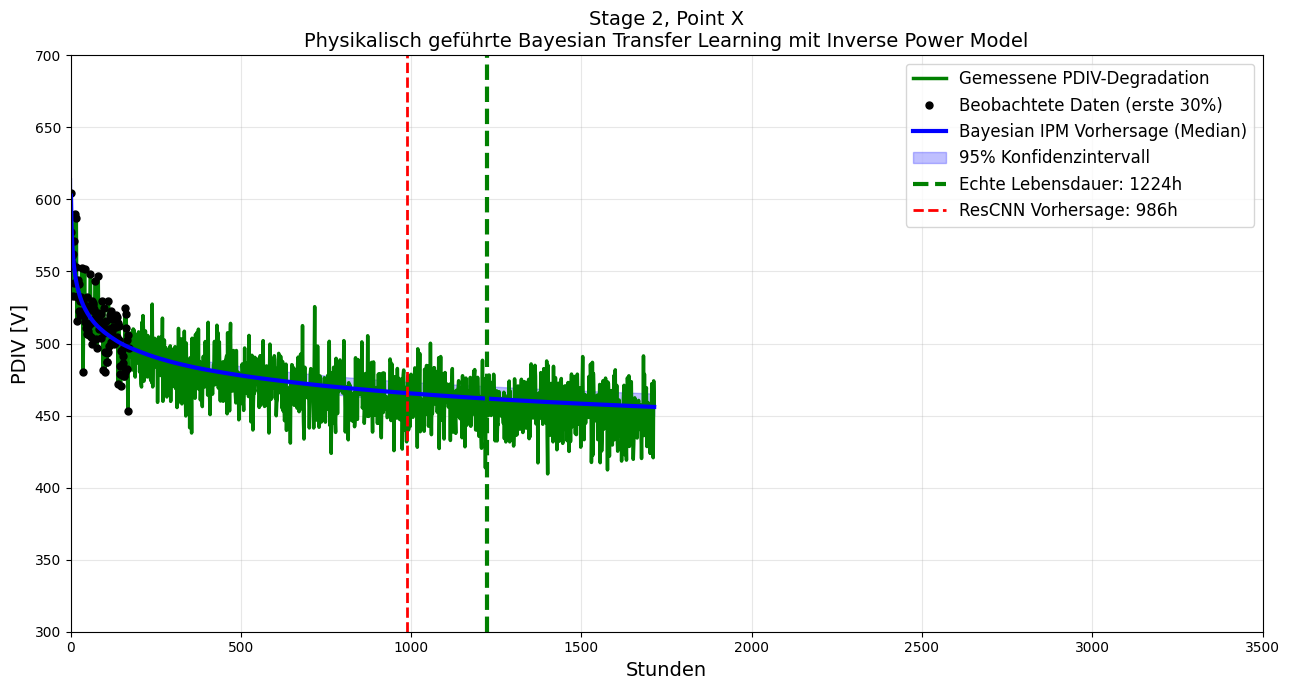

 R² stage 2: 0.9997
 MAE: 0.17 V


In [217]:
#mean_curve_list = [] # Beispiel: Point II (bester Fit in der Dissertation)
for i in range(0,8):
    idx = i #hier ändern, um verschiedene Punkte zu testen 
    motor = test_data[idx]
    t_full = motor['t']
    pdiv_full = motor['PDIV']
    true_life = motor['lifetime']
    cnn_life = pred_life[idx]

    obs_n = int(0.1 * len(t_full))
    t_obs = t_full[:obs_n]
    pdiv_obs = pdiv_full[:obs_n]

    print(f"Stage 2 für Point {motor['point']}, echte Lebensdauer: {true_life}h")

    # MCMC
    ndim, nwalkers = 2, 64
    # Startwerte in der Nähe des wahren Werts (für schnelle Konvergenz)
    p0 = np.array([580, np.log(0.044)]) + 0.05 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t_obs, pdiv_obs, base_fits[i]["cov"]))
    sampler.run_mcmc(p0, 6000, progress=True)
    samples = sampler.get_chain(discard=3000, thin=30, flat=True)

    print(f"Accepted {len(samples)} samples, "
      f"K = {np.mean(samples[:,0]):.1f} ± {np.std(samples[:,0]):.1f}, "
      f"n = {np.exp(np.mean(samples[:,1])):.5f} ± {np.exp(np.std(samples[:,1])) * np.exp(np.mean(samples[:,1])):.5f}")
      
    # Vorhersage
    n_samples = 150
    curves = []
    for i in np.random.randint(len(samples), size=n_samples):
        K, log_n = samples[i]
        curves.append(ipm_model(t_full, K, np.exp(log_n)))
    curves = np.array(curves)

    mean_curve = np.median(curves, axis=0)  # Median ist robuster als Mean
    lower = np.percentile(curves, 2.5, axis=0)
    upper = np.percentile(curves, 97.5, axis=0)

    #mean_curve_list.append(mean_curve)
    # Plot
    plt.figure(figsize=(13, 7))
    plt.plot(t_full, pdiv_full, 'g-', linewidth=2.5, label='Gemessene PDIV-Degradation')
    plt.plot(t_obs, pdiv_obs, 'ko', markersize=5, label='Beobachtete Daten (erste 30%)')
    plt.plot(t_full, mean_curve, 'b-', linewidth=3, label='Bayesian IPM Vorhersage (Median)')
    plt.fill_between(t_full, lower, upper, color='blue', alpha=0.25, label='95% Konfidenzintervall')
    plt.axvline(true_life, color='green', linestyle='--', linewidth=3, label=f'Echte Lebensdauer: {true_life}h')
    plt.axvline(cnn_life, color='red', linestyle='--', linewidth=2, label=f'ResCNN Vorhersage: {cnn_life:.0f}h')
    plt.xlabel('Stunden', fontsize=14)
    plt.ylabel('PDIV [V]', fontsize=14)
    plt.title(f'Stage 2, Point {motor['point']}\nPhysikalisch geführte Bayesian Transfer Learning mit Inverse Power Model', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3500)
    plt.ylim(300, 700)
    plt.tight_layout()
    plt.show()



    from scipy.optimize import curve_fit  
    # das IPM direkt auf die beobachteten Daten fitten
    popt, _ = curve_fit(ipm_model, t_obs, pdiv_obs, p0=[600, 0.04], bounds=([300, 0.001], [800, 0.1]))

    # Berechne den wahren Fit 
    true_fit_curve = ipm_model(t_full, *popt)

    #  vergleichen,  (aber nur die geglätteten Kurven)
    r2_s2 = r2_score(true_fit_curve[obs_n:], mean_curve[obs_n:])
    mae_s2 = mean_absolute_error(true_fit_curve[obs_n:], mean_curve[obs_n:])

    print(f" R² stage 2: {r2_s2:.4f}")
    print(f" MAE: {mae_s2:.2f} V")

## Basismodel mit Unsicherheit

In [457]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import emcee
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [458]:
# Echte Punkte aus der Dissertation (basierend auf Tabellen, da PDF-Suche fehlschlug)
real_points = [
    ("I", 350, 10, 250, 426, 0.0275, 1200),
    ('II', 350, 4, 220, 592, 0.0441, 2610),
    ('III', 400, 4, 250, 475, 0.0104, 740),
    ('IV', 400, 10, 220, 546, 0.0468, 741),
    ('V', 450, 4, 220, 533, 0.0303, 430),
    ('VII', 400, 10, 250, 546, 0.0468, 657),
    ('VIII',400, 4, 220, 559, 0.0418, 1922),
    ('X', 350, 10, 220, 547, 0.0323, 1224),
]

PDIV_THRESHOLD = 400 # Threshold für Failure

def ipm_model(t, K, n):
    return K * t ** (-n)

def generate_ipm_curve(K, n, lifetime_hours, noise_std=15, points=1200):
    t = np.linspace(1, lifetime_hours * 1.4, points)
    PDIV_clean = ipm_model(t, K, n)
    PDIV = PDIV_clean + np.random.normal(0, noise_std, points)
    PDIV = np.clip(PDIV, 300, K + 100)
    return t, PDIV

In [489]:
# Synthetische Trainingsdaten (2000 Kurven, Streuung um real_points)
train_data = []
for i in range(2000):
    base = real_points[np.random.randint(len(real_points))]
    K = np.random.normal(base[4], 30)
    n = np.random.normal(base[5], 0.008)
    K = max(K, 400)
    n = max(n, 0.005)

    PDIV0 = K
    t_search = np.linspace(1, 15000, 30000)    # grobe Suche
    PDIV_search = K * t_search ** (-n)
    lifetime_idx = np.where(PDIV_search <= PDIV_THRESHOLD)[0]
    
    lifetime = int(t_search[lifetime_idx[0]]) if len(lifetime_idx) > 0 else 1200
    t_full, PDIV_full = generate_ipm_curve(K, n, lifetime, noise_std=5)
    train_data.append({
        "id": i, "K": K, "n": n, "lifetime": lifetime, "t": t_full, "PDIV": PDIV_full
    })

print(f"Training data: {len(train_data)} synthetische Motoren")


#Variante 2
#  Daten generieren, Zufälliger/Variabler Grenzwert
#train_data = []
#for i in range(1000):
    #zufällig einen Punkt aus den echten Punkten auswählen, als Basis
    #base = real_points[np.random.randint(len(real_points))]
    #K = np.random.normal(base[4], 30) #+- 30 um den realen K wert
    #n = np.random.normal(base[5], 0.008) #hier auch eine kleine streuung in n
    #K = max(K, 400)
    #n = max(n, 0.005)
    #lifetime = np.random.uniform(200, 3000)
    #t_full, PDIV_full = generate_ipm_curve(K, n, lifetime, noise_std=5)
    #train_data.append({"id": i, "K": K, "n": n, "lifetime": lifetime, "t": t_full, "PDIV": PDIV_full})



Training data: 2000 synthetische Motoren


In [490]:
# Testdaten: Gestreuete Kurven
test_data = []
for p in real_points:
    K_true = np.random.normal(p[4], 30)
    n_true = np.random.normal(p[5], 0.008)
    K_true = max(K_true, 400)
    n_true = max(n_true, 0.005)
    lifetime = p[6]  # Echte Lifetime beibehalten
    t_full, PDIV_full = generate_ipm_curve(K_true, n_true, lifetime, noise_std=5)
    test_data.append({
        "point": p[0], "K_true": K_true, "n_true": n_true,
        "lifetime": lifetime, "t": t_full, "PDIV": PDIV_full
    })

print(f"Test data: {len(test_data)} realistische Punkte")

Test data: 8 realistische Punkte


In [491]:
test_data

[{'point': 'I',
  'K_true': 407.04746458209513,
  'n_true': 0.042158779874230695,
  'lifetime': 1200,
  't': array([1.00000000e+00, 2.40033361e+00, 3.80066722e+00, ...,
         1.67719933e+03, 1.67859967e+03, 1.68000000e+03], shape=(1200,)),
  'PDIV': array([406.96467871, 390.95258111, 392.42483168, ..., 304.20768942,
         304.28490602, 300.        ], shape=(1200,))},
 {'point': 'II',
  'K_true': 557.0405513647296,
  'n_true': 0.04008699274582608,
  'lifetime': 2610,
  't': array([1.00000000e+00, 4.04670559e+00, 7.09341118e+00, ...,
         3.64790659e+03, 3.65095329e+03, 3.65400000e+03], shape=(1200,)),
  'PDIV': array([557.71679535, 528.01561703, 517.60541365, ..., 397.80891087,
         404.53837968, 388.7917192 ], shape=(1200,))},
 {'point': 'III',
  'K_true': 496.13421077143937,
  'n_true': 0.005,
  'lifetime': 740,
  't': array([1.00000000e+00, 1.86321935e+00, 2.72643870e+00, ...,
         1.03427356e+03, 1.03513678e+03, 1.03600000e+03], shape=(1200,)),
  'PDIV': array([488

In [492]:
# Frühe PDIV-Features extrahieren (erste 10%)
def extract_early_pdiv(t_vec, pdiv_vec, early_fraction=0.10):
    n = int(early_fraction * len(pdiv_vec))
    early_t = t_vec[:n]
    early_pdiv = pdiv_vec[:n]
    target_times = np.linspace(50, 800, 80)
    features = []
    for tt in target_times:
        if early_t[-1] < tt:
            features.append(early_pdiv[-1])
        else:
            idx = np.argmin(np.abs(early_t - tt))
            features.append(early_pdiv[idx])
    return np.array(features)

X_train = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in train_data])
y_train = np.array([m["lifetime"] for m in train_data])
X_test = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in test_data])
y_test = np.array([m["lifetime"] for m in test_data])

# Normalisierung
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - X_mean) / (X_std + 1e-8)
X_test_norm = (X_test - X_mean) / (X_std + 1e-8)
y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean) / y_std

In [493]:
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(),
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c)
        )
    
    def forward(self, x):
        return nn.ReLU()(self.net(x) + x)

class ResNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, 7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            ResBlock(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, 1)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x).flatten(1)
        return self.fc(x).squeeze(-1)

In [494]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

Epoch:   0, Loss: 0.347847
Epoch:   1, Loss: 0.178278
Epoch:   2, Loss: 0.137939
Epoch:   3, Loss: 0.108157
Epoch:   4, Loss: 0.080728
Epoch:   5, Loss: 0.084339
Epoch:   6, Loss: 0.075390
Epoch:   7, Loss: 0.064563
Epoch:   8, Loss: 0.071361
Epoch:   9, Loss: 0.065257
Epoch:  10, Loss: 0.050885
Epoch:  11, Loss: 0.038227
Epoch:  12, Loss: 0.036171
Epoch:  13, Loss: 0.038608
Epoch:  14, Loss: 0.037137
Epoch:  15, Loss: 0.043489
Epoch:  16, Loss: 0.036985
Epoch:  17, Loss: 0.029106
Epoch:  18, Loss: 0.031407
Epoch:  19, Loss: 0.023012
Epoch:  20, Loss: 0.020710
Epoch:  21, Loss: 0.031591
Epoch:  22, Loss: 0.027563
Epoch:  23, Loss: 0.023138
Epoch:  24, Loss: 0.019798
Epoch:  25, Loss: 0.016457
Epoch:  26, Loss: 0.020854
Epoch:  27, Loss: 0.021899
Epoch:  28, Loss: 0.022339
Epoch:  29, Loss: 0.018302
Epoch:  30, Loss: 0.017672
Epoch:  31, Loss: 0.019775
Epoch:  32, Loss: 0.026744
Epoch:  33, Loss: 0.016845
Epoch:  34, Loss: 0.017807
Epoch:  35, Loss: 0.011222
Epoch:  36, Loss: 0.013310
E

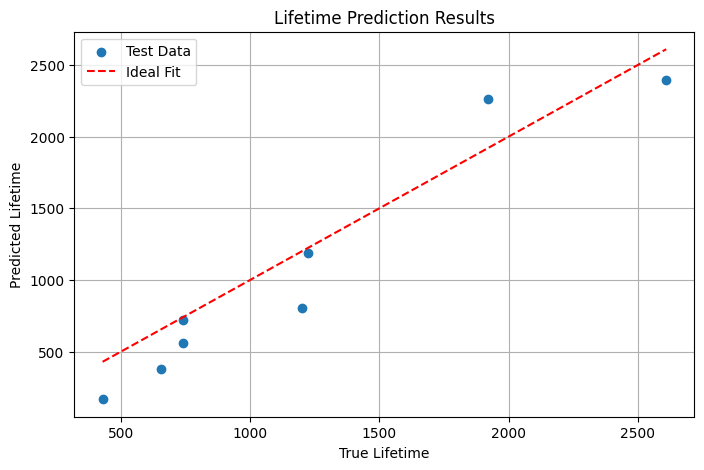

In [495]:
model = ResNetCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.0015, weight_decay=1e-5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_norm), torch.FloatTensor(y_train_norm)),
                    batch_size=32, shuffle=True)

best_loss = float("inf")
best_model_state = None
for epoch in range(70):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    epoch_loss /= len(loader)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_state = model.state_dict().copy()

    #if epoch % 10 == 0:
    print(f"Epoch: {epoch:3d}, Loss: {epoch_loss:.6f}")

model.load_state_dict(best_model_state)
print("Training finished.")

# Evaluation
model.eval()
with torch.no_grad():
    pred_norm = model(torch.FloatTensor(X_test_norm).to(device)).cpu().numpy()
    pred_life = pred_norm * y_std + y_mean

mae = mean_absolute_error(y_test, pred_life)
rmse = np.sqrt(mean_squared_error(y_test, pred_life))
mape = mean_absolute_percentage_error(y_test, pred_life)
r2 = r2_score(y_test, pred_life)
std_dev_prediction_error = np.std(y_test - pred_life)  # Für Bayesian Prior v0

print("Lifetime Prediction Performance (Test Set) ")
print(f"MAE: {mae:.3f} hours")
print(f"RMSE: {rmse:.3f} hours")
print(f"MAPE: {mape:.3f} %")
print(f"R²: {r2:.4f}")
print(f"Std Dev of Errors: {std_dev_prediction_error:.2f} (used for Bayesian prior 'v0')")


plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_life, label='Test Data')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Ideal Fit')
plt.title("Lifetime Prediction Results")
plt.xlabel("True Lifetime")
plt.ylabel("Predicted Lifetime")
plt.legend()
plt.grid(True)
plt.show()


 Target Point: II


100%|██████████| 10000/10000 [00:11<00:00, 848.57it/s]


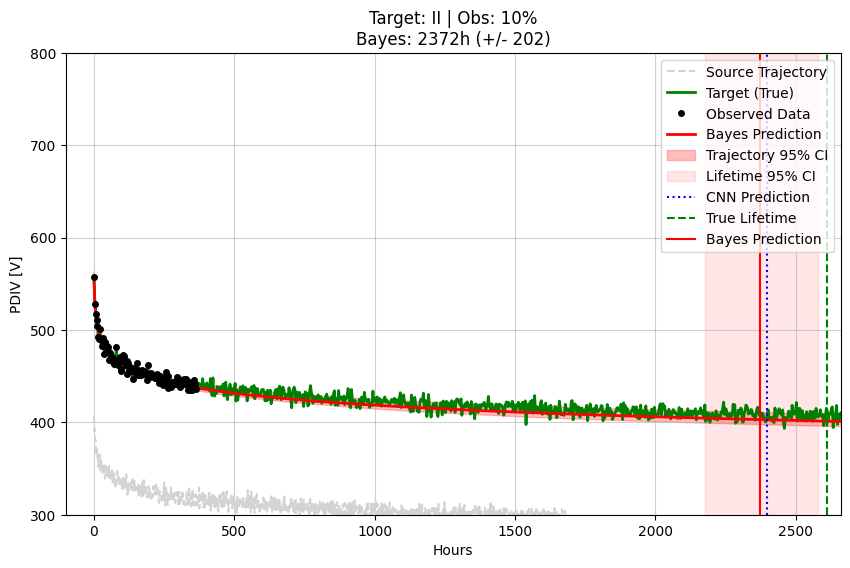

-----
(Test Dataset, ab 10%):
True Lifetime: 2610h | CNN: 2397h | Bayes: 2372h (+/- 202)
 R² Score: 0.6057
 Trajectory MAE:5.71 V
 Lifetime Error:238 h
-----

 Target Point: III


100%|██████████| 10000/10000 [00:10<00:00, 930.43it/s]


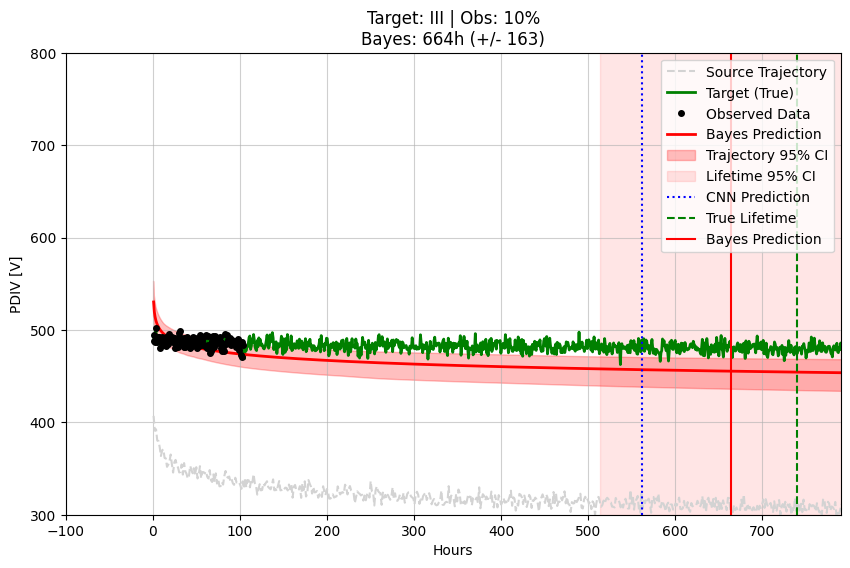

-----
(Test Dataset, ab 10%):
True Lifetime: 740h | CNN: 562h | Bayes: 664h (+/- 163)
 R² Score: -18.7186
 Trajectory MAE:22.82 V
 Lifetime Error:76 h
-----

 Target Point: IV


100%|██████████| 10000/10000 [00:11<00:00, 859.91it/s]


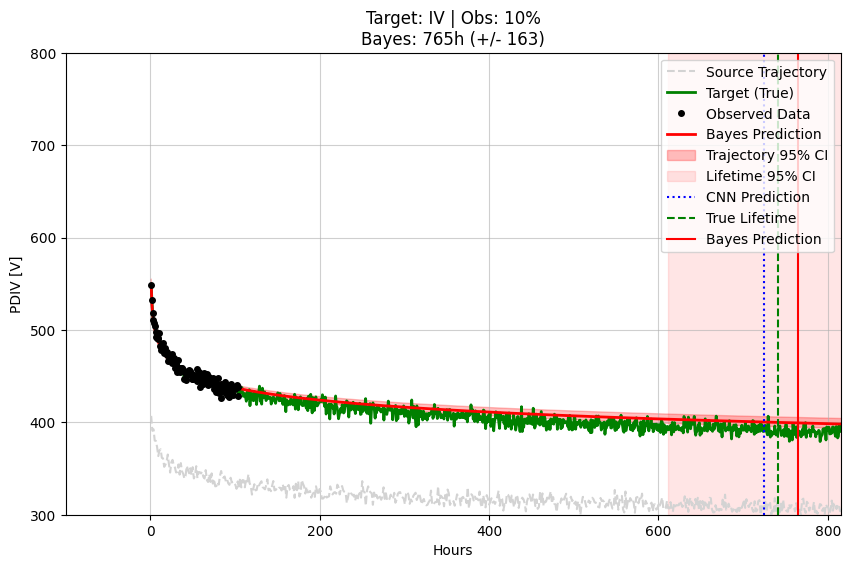

-----
(Test Dataset, ab 10%):
True Lifetime: 741h | CNN: 725h | Bayes: 765h (+/- 163)
 R² Score: 0.5278
 Trajectory MAE:7.73 V
 Lifetime Error:24 h
-----

 Target Point: V


100%|██████████| 10000/10000 [00:04<00:00, 2412.76it/s]


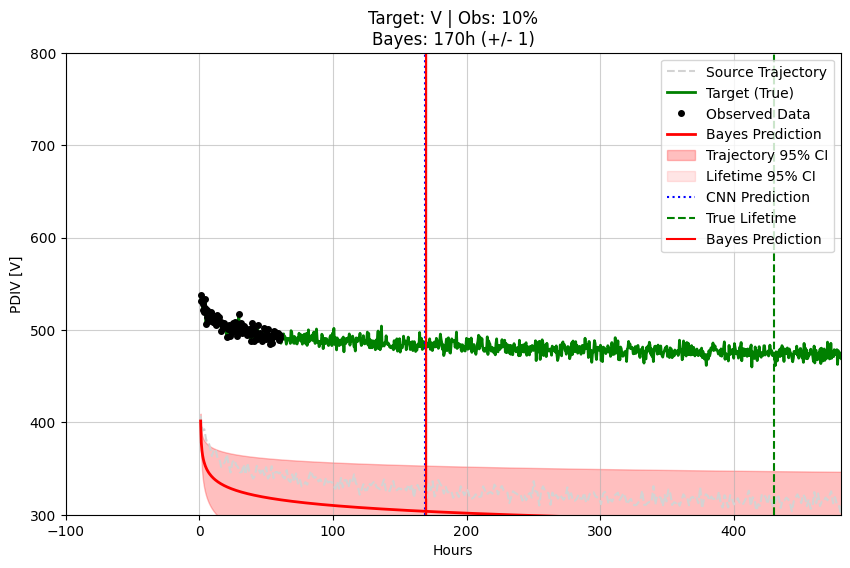

-----
(Test Dataset, ab 10%):
True Lifetime: 430h | CNN: 169h | Bayes: 170h (+/- 1)
 R² Score: -568.7120
 Trajectory MAE:180.84 V
 Lifetime Error:260 h
-----

 Target Point: VII


100%|██████████| 10000/10000 [00:04<00:00, 2219.41it/s]


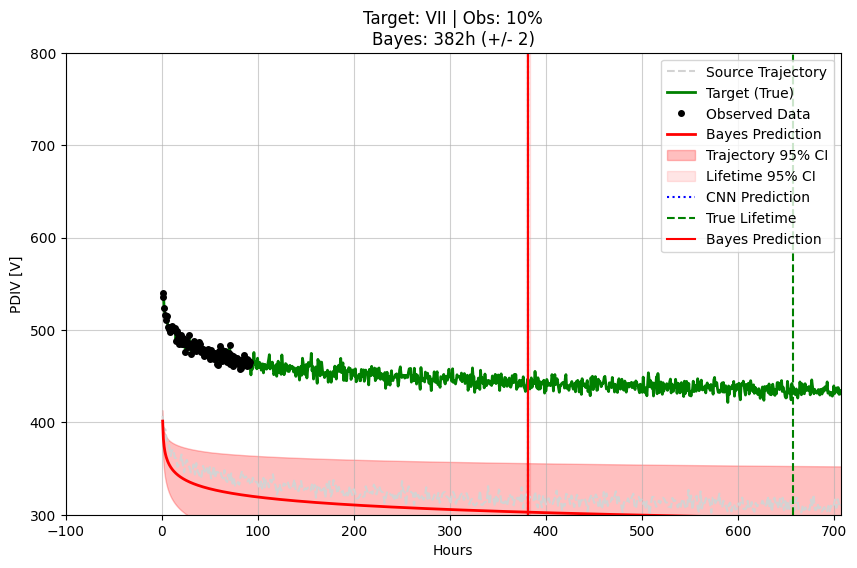

-----
(Test Dataset, ab 10%):
True Lifetime: 657h | CNN: 381h | Bayes: 382h (+/- 2)
 R² Score: -195.8748
 Trajectory MAE:139.93 V
 Lifetime Error:275 h
-----

 Target Point: VIII


100%|██████████| 10000/10000 [00:11<00:00, 875.97it/s]


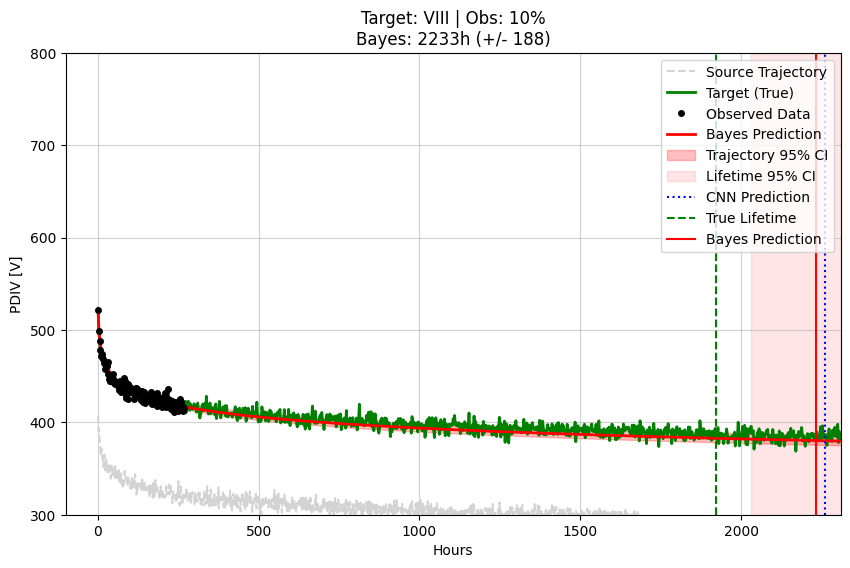

-----
(Test Dataset, ab 10%):
True Lifetime: 1922h | CNN: 2260h | Bayes: 2233h (+/- 188)
 R² Score: 0.6175
 Trajectory MAE:5.16 V
 Lifetime Error:311 h
-----

 Target Point: X


100%|██████████| 10000/10000 [00:11<00:00, 882.43it/s]


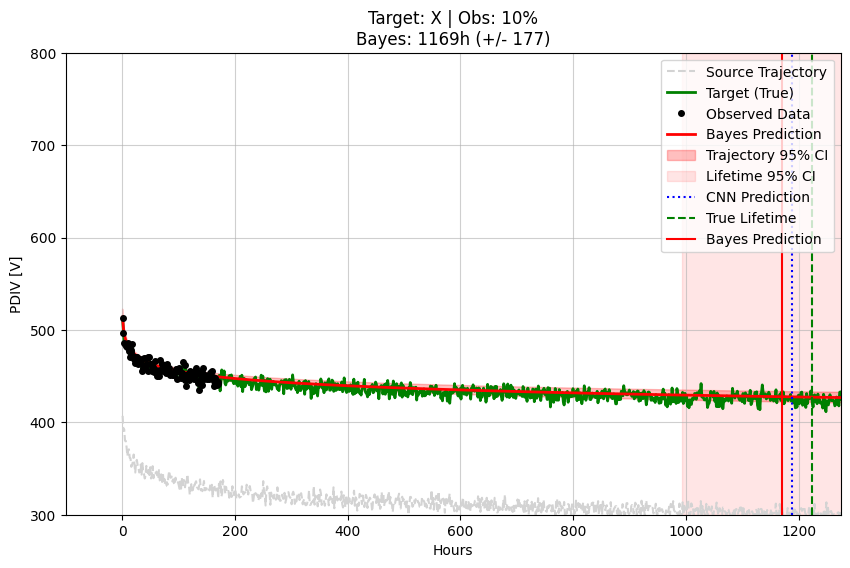

-----
(Test Dataset, ab 10%):
True Lifetime: 1224h | CNN: 1188h | Bayes: 1169h (+/- 177)
 R² Score: 0.5322
 Trajectory MAE:4.44 V
 Lifetime Error:55 h
-----


In [496]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import torch
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def ipm_model(t, K, n):
    t_safe = np.maximum(t, 1e-5) 
    return K * (t_safe ** (-n))

def transferred_model_full_bayes(transfer_params, t_new, base_params_variable):
    rho0, lambda0, rho1, lambda1 = transfer_params
    K_var, n_var = base_params_variable
    
    t_old = rho0 * t_new + lambda0
    pdiv_old = ipm_model(t_old, K_var, n_var)
    pdiv_new = rho1 * pdiv_old + lambda1
    return pdiv_new

# Log-Probability (mit min SIGMA)
def log_probability_full_bayes(params, t_obs, pdiv_obs, source_fit_stats, predicted_lifetime, v0):
    rho0, rho1, lambda1, log_sigma, K_var, n_var = params
    source_t_start, source_life, mu_K, std_K, mu_n, std_n = source_fit_stats

    lambda0 = source_t_start - rho0 * t_obs[0]

    # Grenzen
    if not (0.2 < rho0 < 3.0): return -np.inf
    if not (0.5 < rho1 < 1.5): return -np.inf
    if not (-200 < lambda1 < 200): return -np.inf
    if not (-5 < log_sigma < 5): return -np.inf
    
    # Grenten für K und n
    if not (mu_K * 0.5 < K_var < mu_K * 1.5): return -np.inf
    if not (mu_n * 0.5 < n_var < mu_n * 1.5): return -np.inf

    #Likelhoodd
    transfer_params = [rho0, lambda0, rho1, lambda1]
    base_vars = [K_var, n_var]
    pdiv_pred = transferred_model_full_bayes(transfer_params, t_obs, base_vars)
    
    sigma = np.exp(log_sigma)
    
    # SIGMA Grenze
    if sigma < 3.0: 
        return -np.inf 
        
    diff = pdiv_obs - pdiv_pred
    log_likelihood_val = -0.5 * np.sum((diff / sigma) ** 2) - len(t_obs) * np.log(sigma)
    
    if not np.isfinite(log_likelihood_val):
        return -np.inf

    # PRIOR Werte
    log_prior_base_K = -0.5 * ((K_var - mu_K) / std_K) ** 2
    log_prior_base_n = -0.5 * ((n_var - mu_n) / std_n) ** 2

    current_life_implied = (source_life - lambda0) / rho0
    effective_v0 = min(v0, 100.0) 
    log_prior_cnn = -0.5 * ((current_life_implied - predicted_lifetime) / effective_v0) ** 2

    log_prior_rho1 = -0.5 * ((rho1 - 1.0) / 0.1) ** 2
    log_prior_lambda1 = -0.5 * ((lambda1 - 0.0) / 50.0) ** 2
    log_prior_rho0 = -0.5 * ((rho0 - 1.0) / 0.5) ** 2

    return log_likelihood_val + log_prior_base_K + log_prior_base_n + log_prior_cnn + log_prior_rho1 + log_prior_lambda1 + log_prior_rho0


#Schleife

source_index = 0

for i in range(1, len(test_data)):
    target_index = i
    obs_fraction = 0.1 

    source_motor = test_data[source_index]
    target_motor = test_data[target_index]
    
    source_t = source_motor['t']
    source_pdiv = source_motor['PDIV']
    target_t_full = target_motor['t']
    target_pdiv_full = target_motor['PDIV']
    true_lifetime = target_motor['lifetime']
    predicted_lifetime_val = pred_life[target_index]

    print(f"\n Target Point: {target_motor['point']}")

    # Source Fit
  
    popt_source, pcov_source = curve_fit(
        ipm_model, source_t, source_pdiv, 
        p0=[600, 0.04], bounds=([300, 0.001], [2000, 0.5]), 
        maxfev=5000
    )
    perr_source = np.sqrt(np.diag(pcov_source))
    
    # Unsicherheit (10%,15%)
    std_K = max(perr_source[0], popt_source[0] * 0.10) 
    std_n = max(perr_source[1], popt_source[1] * 0.15)
    
    # print(f" Source Unsicherheit: K_std={std_K:.2f}, n_std={std_n:.4f}")
    source_fit_stats = (source_t[0], source_motor['lifetime'], popt_source[0], std_K, popt_source[1], std_n)
        

    # MCMC
    obs_n = max(5, int(obs_fraction * len(target_t_full)))
    
    # nur jeden 10. Punkt für den Fit. verringert Dominanz der erstne n Punkte der Daten
    thinning_step = 10 
    
    # Daten für den Fit
    t_fit = target_t_full[:obs_n:thinning_step]
    pdiv_fit = target_pdiv_full[:obs_n:thinning_step]
    
    # Daten für Plotting (vollständig)
    t_plot_obs = target_t_full[:obs_n]
    pdiv_plot_obs = target_pdiv_full[:obs_n]

    n_walkers, n_dim = 64, 6 
    n_steps, burn_in = 10000, 2000
    
    rho0_start = source_fit_stats[1] / predicted_lifetime_val
    start_pos = np.array([
        rho0_start, 1.0, 0.0, np.log(10.0), popt_source[0], popt_source[1]
    ])
    p0 = start_pos + 1e-2 * np.random.randn(n_walkers, n_dim)
    
    cnn_uncertainty = 100.0 
    
    # Hie t_fit und pdiv_fit (die ausgedünnten Daten) überg eben 
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_full_bayes, args=(
        t_fit, pdiv_fit, source_fit_stats, predicted_lifetime_val, cnn_uncertainty
    ))
    
    sampler.run_mcmc(p0, n_steps, progress=True)
    flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

    # Vorhersagen
    predictions = []
    lifetime_predictions = []
    
    random_indices = np.random.randint(len(flat_samples), size=400)
    
    for idx in random_indices:
        rho0, rho1, lambda1, _, K_samp, n_samp = flat_samples[idx]
        
        # Lambda0 muss auf t_fit[0] bezogen werden, damit die Kurve stimmt
        lambda0 = source_fit_stats[0] - rho0 * t_fit[0]
        
        
        var_base_params = [K_samp, n_samp]
        # vorhersagen aber für ALLE Zeiten (target_t_full)
        pred_curve = transferred_model_full_bayes(
            [rho0, lambda0, rho1, lambda1], target_t_full, var_base_params
        )
        predictions.append(pred_curve)
        calc_life = (source_fit_stats[1] - lambda0) / rho0
        lifetime_predictions.append(calc_life)
        
    mean_prediction = np.mean(np.array(predictions), axis=0)
    lower_ci_curve, upper_ci_curve = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)
    
    life_lower = np.percentile(lifetime_predictions, 2.5)
    life_upper = np.percentile(lifetime_predictions, 97.5)
    bayes_lifetime_mean = np.median(lifetime_predictions)
    bayes_uncertainty_half = (life_upper - life_lower) / 2

    # Relative Genauigkeit berechnen
    # 1 - (|True - Pred| / True)
    #life_err = abs(bayes_lifetime_mean - true_lifetime)
    #relative_accuracy = (1 - (life_err / true_lifetime)) * 100

    # 2. Coverage Score (JA/NEIN)
    # Liegt die True Lifetime zwischen Lower und Upper CI?
    #is_covered = (life_lower <= true_lifetime <= life_upper)
    #coverage_text = "JA" if is_covered else "NEIN"

    # Plotten
    plt.figure(figsize=(10, 6))
    plt.plot(source_t, source_pdiv, color='lightgray', linestyle='--', label='Source Trajectory')
    plt.plot(target_t_full, target_pdiv_full, 'g-', lw=2, label='Target (True)')
    # die erstne n beobachteten Punkte (schwarz)
    plt.plot(t_plot_obs, pdiv_plot_obs, 'k.', markersize=8, zorder=5, label='Observed Data')
    plt.plot(target_t_full, mean_prediction, 'r-', lw=2, label='Bayes Prediction')  
    plt.fill_between(target_t_full, lower_ci_curve, upper_ci_curve, color='red', alpha=0.25, label='Trajectory 95% CI') # Alpha etwas erhöht

    plt.axvspan(life_lower, life_upper, color='red', alpha=0.1, label='Lifetime 95% CI')
    
    plt.axvline(x=predicted_lifetime_val, color='blue', linestyle=':', label='CNN Prediction')
    plt.axvline(x=true_lifetime, color='green', linestyle='--', label='True Lifetime')
    plt.axvline(x=bayes_lifetime_mean, color='red', linestyle='-', label='Bayes Prediction')
    
    plt.title(f"Target: {target_motor['point']} | Obs: {obs_fraction*100:.0f}%\nBayes: {bayes_lifetime_mean:.0f}h (+/- {bayes_uncertainty_half:.0f})")
    plt.xlabel('Hours')
    plt.ylabel('PDIV [V]')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.6)
    plt.ylim(300, 800)
    plt.xlim(-100, max(true_lifetime,predicted_lifetime_val, bayes_lifetime_mean) +50)
    plt.show()
    
    # Metriken
    if obs_n < len(target_t_full):
        y_true_test = target_pdiv_full[obs_n:]
        y_pred_test = mean_prediction[obs_n:]
        
        mae = mean_absolute_error(y_true_test, y_pred_test)
        rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
        r2 = r2_score(y_true_test, y_pred_test)
        life_err = abs(bayes_lifetime_mean - true_lifetime)
        
        print("-" * 5)
        print(f"(Test Dataset, ab {obs_fraction*100:.0f}%):")
        print(f"True Lifetime: {true_lifetime:.0f}h | CNN: {predicted_lifetime_val:.0f}h | Bayes: {bayes_lifetime_mean:.0f}h (+/- {bayes_uncertainty_half:.0f})")
        print(f" R² Score: {r2:.4f}")
        #print(f" Relative Accuracy: {relative_accuracy:.2f} %") 
        #print(f" Coverage Score:    {coverage_text} (True Life im Intervall [{life_lower:.0f}, {life_upper:.0f}])")
        print(f" Trajectory MAE:{mae:.2f} V")
        print(f" Lifetime Error:{life_err:.0f} h")
        print("-" * 5)


In [351]:
pred_life

array([1198.0542018 , 2553.65230073,  684.42183303,  657.76082732,
        448.67048765,  662.10176089, 1896.95413429, 1215.19692931])

In [419]:
#predictions